In [2]:
from google.colab import files


uploaded = files.upload()

import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.xls")

Saving WA_Fn-UseC_-Telco-Customer-Churn.xls to WA_Fn-UseC_-Telco-Customer-Churn (1).xls


In [7]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


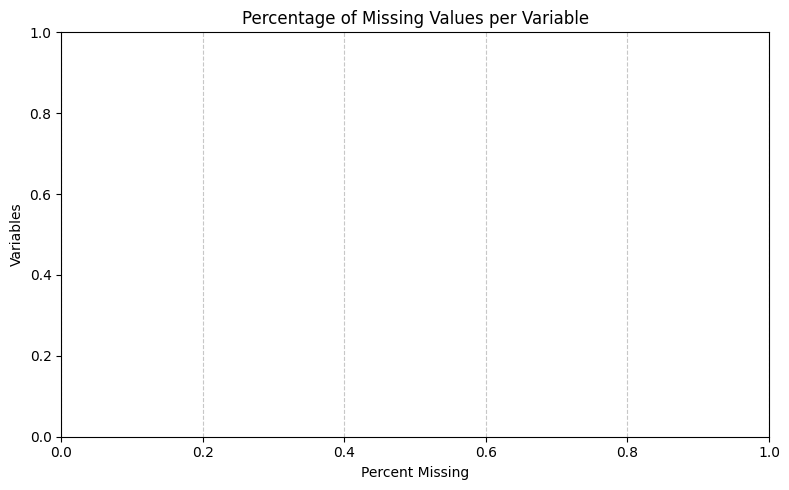

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of missing values for each column
missing_data = df.isnull().sum() / len(df)

# Filter out columns with no missing data (if any)
missing_data = missing_data[missing_data > 0]

# Convert the Series to a DataFrame and reset index, then rename columns
missing_data_df = missing_data.reset_index()
missing_data_df.columns = ['variables', 'percent_missing']

# Sort the data for better visualization
missing_data_df_sorted = missing_data_df.sort_values(by='percent_missing', ascending=True)

# Set plot size
plt.figure(figsize=(8, 5)) # Increased width for better label visibility

# Create a horizontal bar plot using seaborn
sns.barplot(x='percent_missing', y='variables', data=missing_data_df_sorted, color='red')

# Add labels and title
plt.xlabel('Percent Missing')
plt.ylabel('Variables')
plt.title('Percentage of Missing Values per Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd

# Remove rows with any missing values
df = df.dropna()

# Convert 'SeniorCitizen' to 'YES'/'NO' and then to a categorical type
df['SeniorCitizen'] = pd.Series(np.where(df['SeniorCitizen'] == 1, 'YES', 'NO')).astype('category')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

/tmp/ipykernel_14135/3764989283.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y='percent', data=churn_counts, palette=['#FC4E07', '#E7B800'])


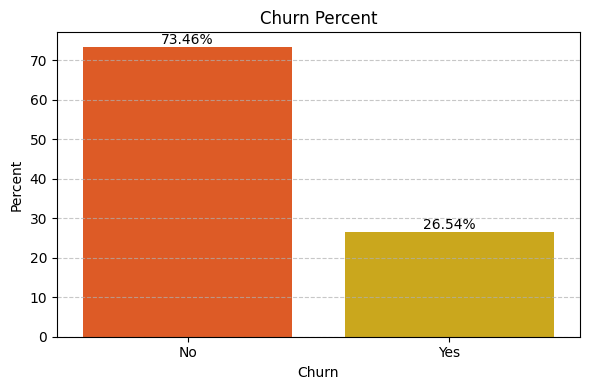

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn percentage
churn_counts = df['Churn'].value_counts(normalize=True).reset_index()
churn_counts.columns = ['Churn', 'percent']
churn_counts['percent'] = churn_counts['percent'] * 100

# Sort for consistent plotting (optional, but good practice if order matters)
churn_counts = churn_counts.sort_values(by='percent', ascending=False)

# Set plot size
plt.figure(figsize=(6, 4))

# Create the bar plot
sns.barplot(x='Churn', y='percent', data=churn_counts, palette=['#FC4E07', '#E7B800'])

# Add percentage labels on top of the bars
for index, row in churn_counts.iterrows():
    plt.text(index, row['percent'], f'{row['percent']:.2f}%', color='black', ha="center", va='bottom')

# Add labels and title
plt.xlabel('Churn')
plt.ylabel('Percent')
plt.title('Churn Percent')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

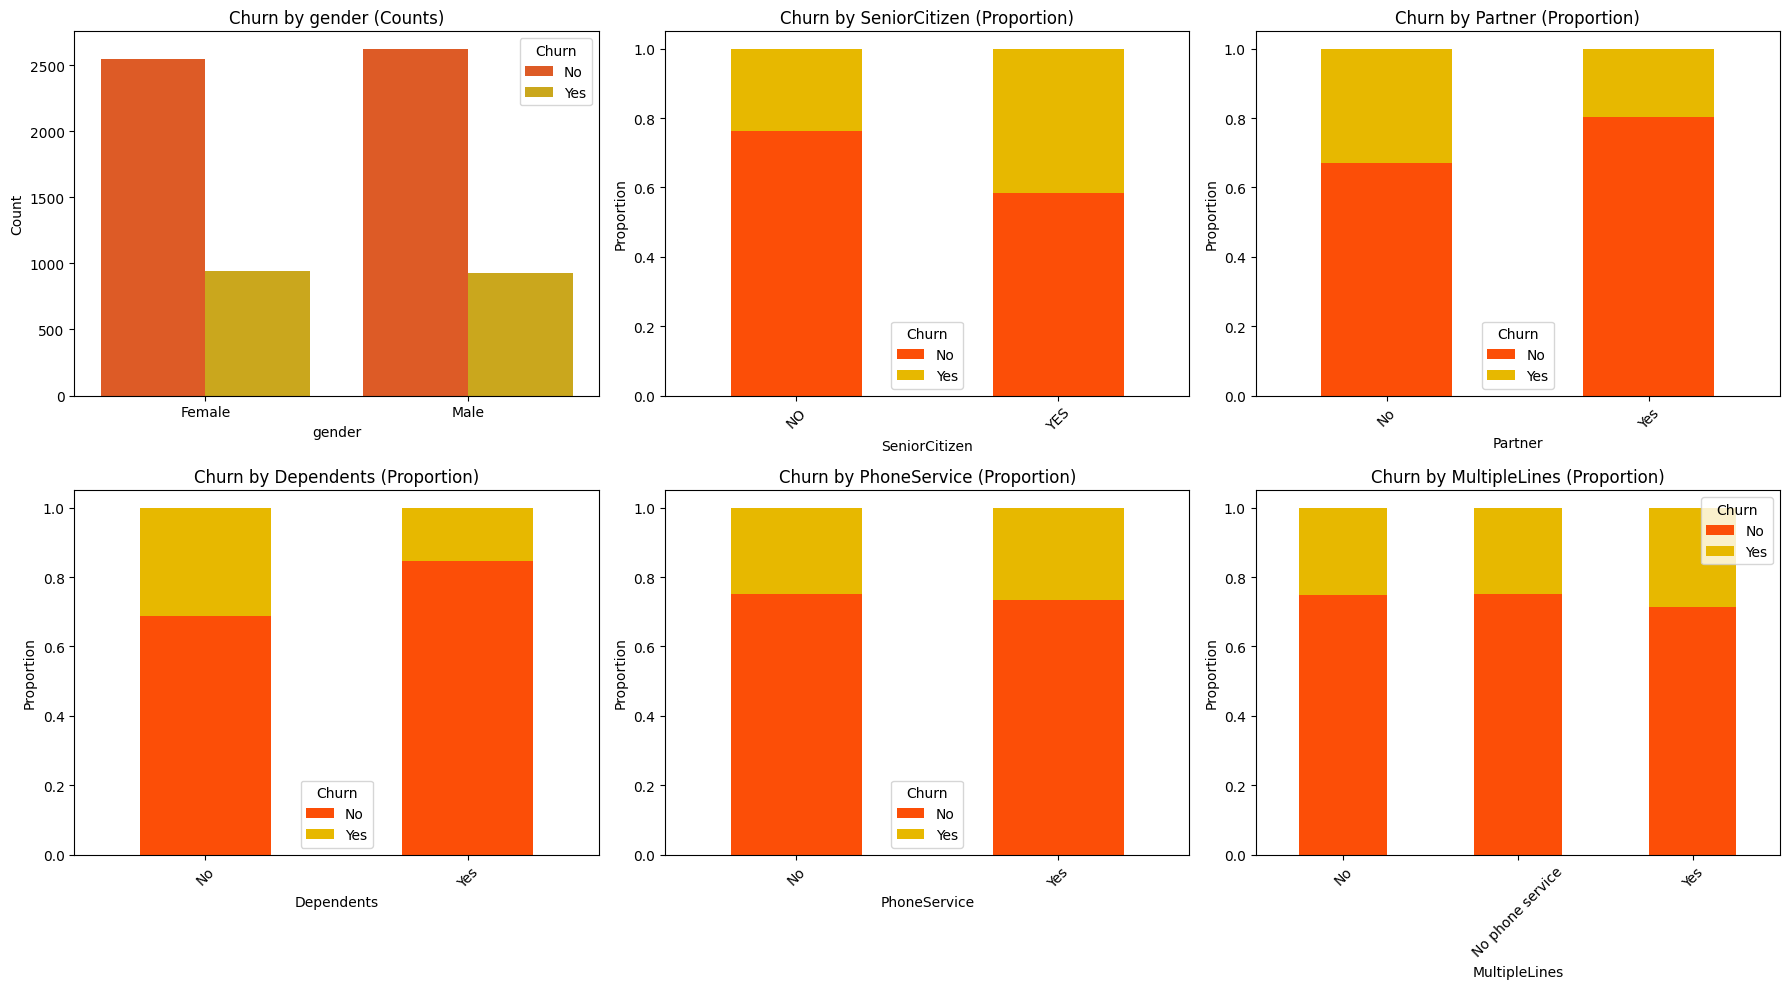

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the categorical columns to plot
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines']

# Define palette for Churn 'No' and 'Yes' for consistency with previous plots
churn_palette = {'No': '#FC4E07', 'Yes': '#E7B800'}

# Determine grid size (e.g., 2 rows, 3 columns)
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5)) # Adjust figsize as needed
axes = axes.flatten() # Flatten for easier iteration over subplots

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    if col == 'gender':
        # Plot counts for gender (R's geom_bar() without position='fill')
        sns.countplot(data=df, x=col, hue='Churn', ax=ax, palette=churn_palette)
        ax.set_title(f'Churn by {col} (Counts)')
        ax.set_ylabel('Count')
    else:
        # Plot percentages for other columns (R's geom_bar(position='fill'))
        # Calculate percentages of Churn within each category of `col`
        cross_tab_prop = pd.crosstab(df[col], df['Churn'], normalize='index')

        # Ensure 'No' and 'Yes' columns exist and are ordered correctly for consistent colors
        # This handles cases where a category might only have 'No' or 'Yes' churn
        cols_order = ['No', 'Yes']
        for c in cols_order:
            if c not in cross_tab_prop.columns:
                cross_tab_prop[c] = 0
        cross_tab_prop = cross_tab_prop[cols_order] # Reorder to match palette

        # Map palette colors to the columns for plotting
        colors_for_plot = [churn_palette[c] for c in cross_tab_prop.columns]

        cross_tab_prop.plot(kind='bar', stacked=True, ax=ax, color=colors_for_plot)
        ax.set_title(f'Churn by {col} (Proportion)')
        ax.set_ylabel('Proportion')
        ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

    ax.set_xlabel(col)
    ax.legend(title='Churn') # Add legend to each subplot

# Hide any unused subplots if the number of plots is not a perfect multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show() # Display the plot

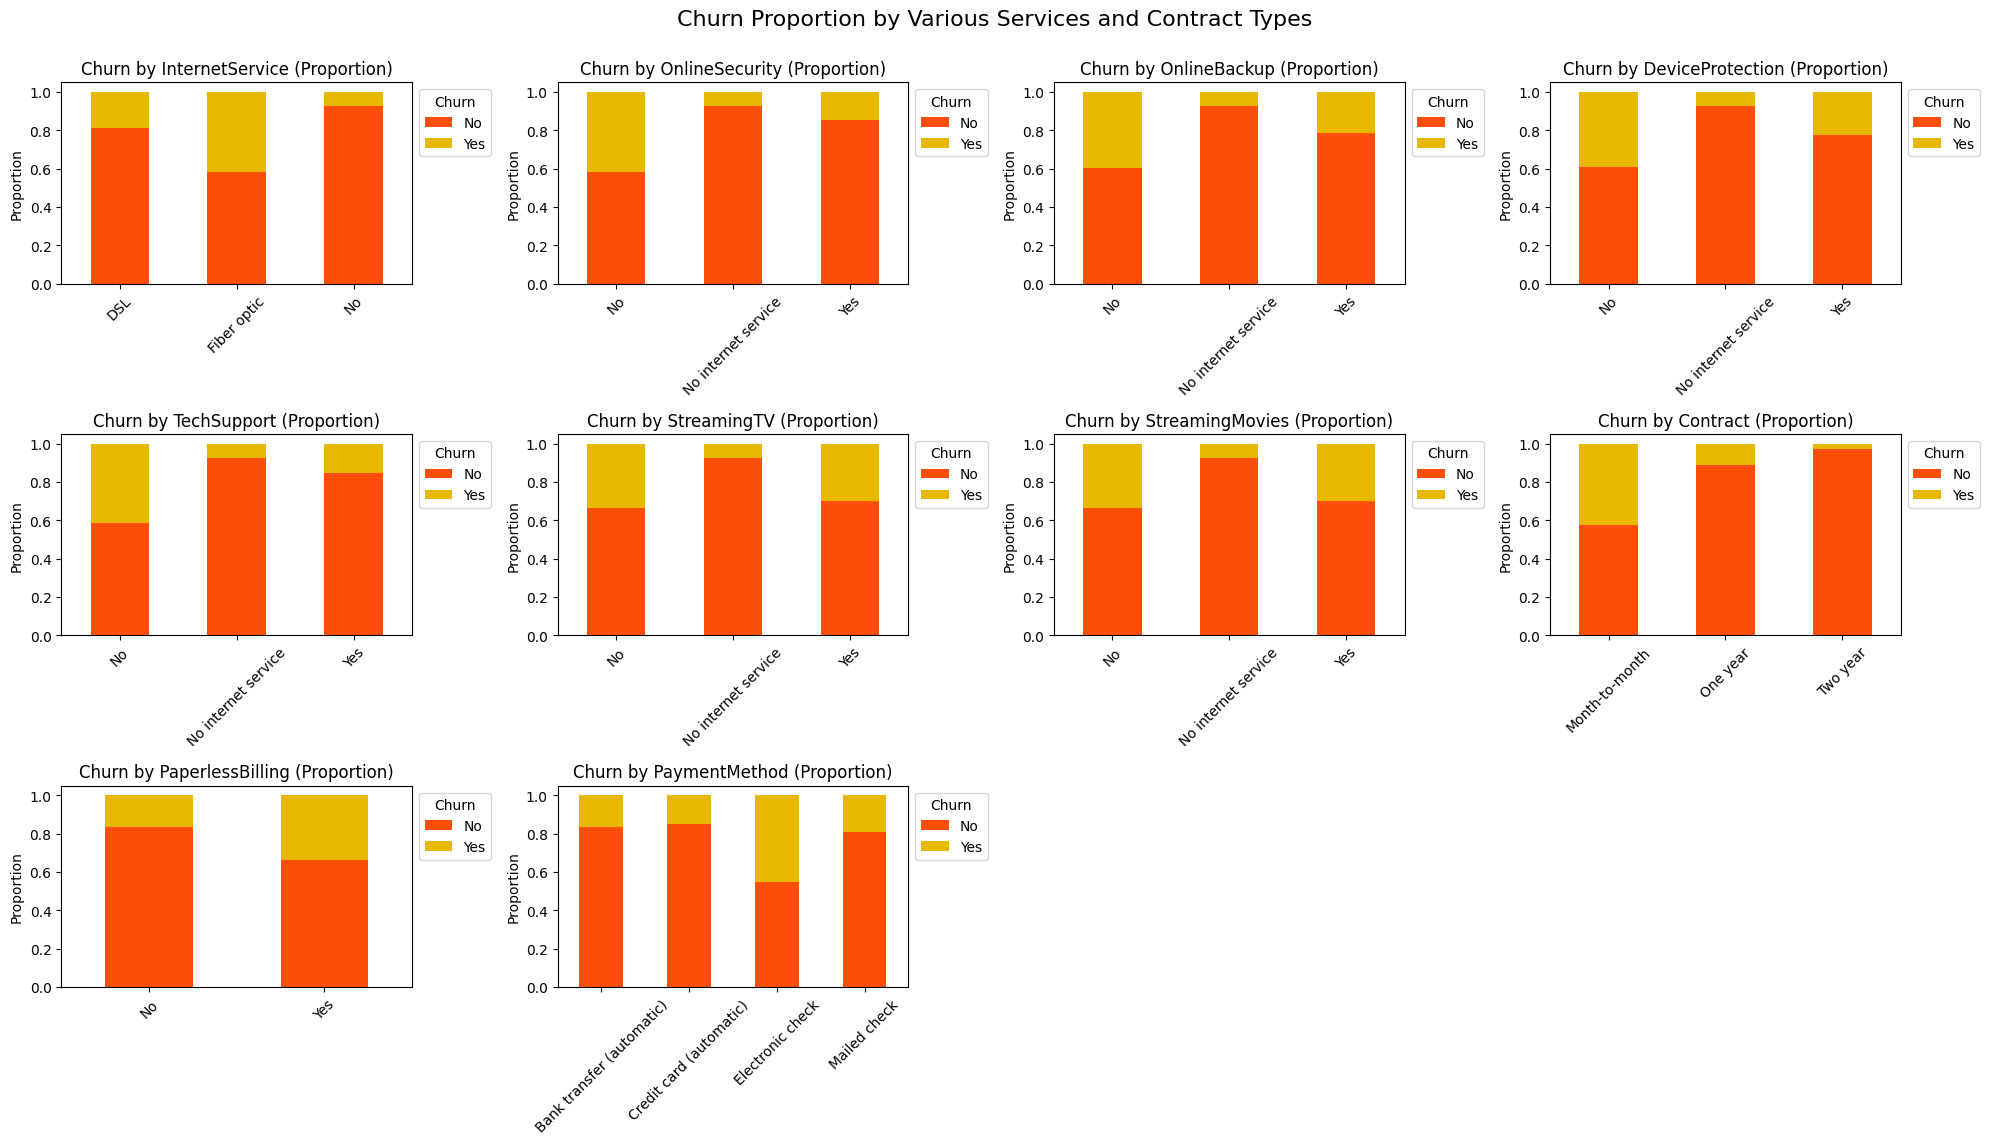

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the categorical columns to plot from the R code's intent
categorical_cols_services = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

# Define palette for Churn 'No' and 'Yes' for consistency
churn_palette = {'No': '#FC4E07', 'Yes': '#E7B800'}

# Determine grid size (e.g., 3 rows, 4 columns for 10 plots)
n_cols = 4
n_rows = int(np.ceil(len(categorical_cols_services) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4)) # Adjust figsize as needed
axes = axes.flatten() # Flatten for easier iteration over subplots

for i, col in enumerate(categorical_cols_services):
    ax = axes[i]

    # Calculate percentages of Churn within each category of `col`
    cross_tab_prop = pd.crosstab(df[col], df['Churn'], normalize='index')

    # Ensure 'No' and 'Yes' columns exist and are ordered correctly for consistent colors
    # This handles cases where a category might only have 'No' or 'Yes' churn
    cols_order = ['No', 'Yes']
    for c in cols_order:
        if c not in cross_tab_prop.columns:
            cross_tab_prop[c] = 0
    cross_tab_prop = cross_tab_prop[cols_order] # Reorder to match palette

    # Map palette colors to the columns for plotting
    colors_for_plot = [churn_palette[c] for c in cross_tab_prop.columns]

    cross_tab_prop.plot(kind='bar', stacked=True, ax=ax, color=colors_for_plot)
    ax.set_title(f'Churn by {col} (Proportion)')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability
    ax.set_xlabel('') # Remove x-label to avoid redundancy with tick labels
    ax.legend(title='Churn', loc='upper left', bbox_to_anchor=(1, 1)) # Add legend to each subplot

# Hide any unused subplots if the number of plots is not a perfect multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust subplot parameters for a tight layout, leaving space for title
plt.suptitle('Churn Proportion by Various Services and Contract Types', fontsize=16) # Add a main title
plt.show() # Display the plot

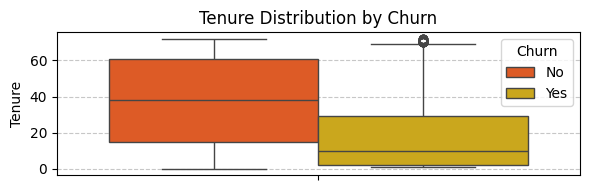

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot size based on the R options (repr.plot.width, repr.plot.height)
plt.figure(figsize=(6, 2))

# Create the boxplot using seaborn
sns.boxplot(data=df, y='tenure', hue='Churn', palette={'No': '#FC4E07', 'Yes': '#E7B800'})

# Apply theme_bw equivalent and xlab(" ") equivalent
plt.title('Tenure Distribution by Churn')
plt.xlabel('') # Replicates xlab(" ")
plt.ylabel('Tenure')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Basic grid similar to theme_bw

plt.tight_layout()
plt.show()

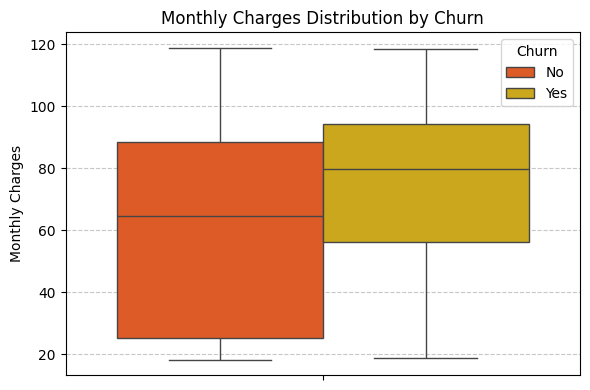

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot size based on the R options (e.g., width, height)
plt.figure(figsize=(6, 4)) # Adjust size as needed

# Create the boxplot using seaborn
sns.boxplot(data=df, y='MonthlyCharges', hue='Churn', palette={'No': '#FC4E07', 'Yes': '#E7B800'})

# Apply theme_bw equivalent and xlab(" ") equivalent
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('') # Replicates xlab(" ")
plt.ylabel('Monthly Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Basic grid similar to theme_bw

plt.tight_layout()
plt.show()

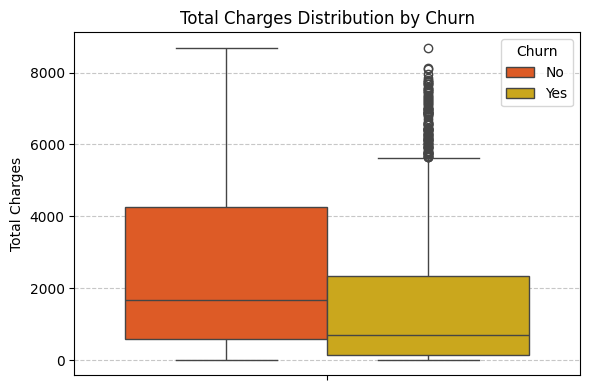

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop rows where 'TotalCharges' is NaN after conversion (if any)
df.dropna(subset=['TotalCharges'], inplace=True)

# Set plot size based on previous plots
plt.figure(figsize=(6, 4))

# Create the boxplot using seaborn
sns.boxplot(data=df, y='TotalCharges', hue='Churn', palette={'No': '#FC4E07', 'Yes': '#E7B800'})

# Apply theme_bw equivalent and xlab(" ") equivalent
plt.title('Total Charges Distribution by Churn')
plt.xlabel('') # Replicates xlab(" ")
plt.ylabel('Total Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Basic grid similar to theme_bw

plt.tight_layout()
plt.show()

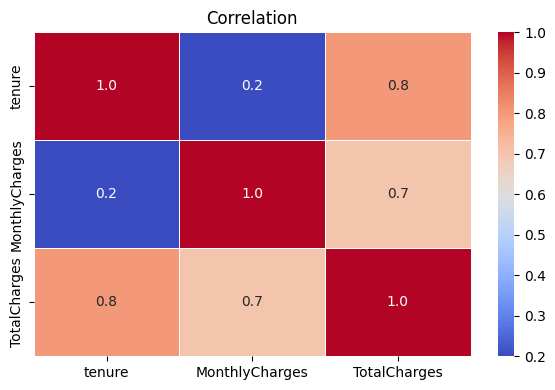

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numerical columns and calculate the correlation matrix
# The R code uses 'telco', which corresponds to 'df' here.
# The R code also rounds to 1 decimal place.
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr().round(1)

# Set plot size based on the R options
plt.figure(figsize=(6, 4))

# Create the correlation heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=.5)

# Add title and center it as intended by R's theme(plot.title = element_text(hjust = 0.5))
plt.title('Correlation', ha='center')

plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# The R code was trying to get outliers from a boxplot, which is not directly plotted.
# However, the previous Python code for boxplots already displays the outliers visually.
# If you specifically need the outlier values, you can calculate them, but for now,
# I will remove the R code as it causes a SyntaxError.
# The boxplot of 'tenure' by 'Churn' is already available in a previous cell (nBrr3bSRM1Hu).

In [37]:
import numpy as np

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['MonthlyCharges'] < lower_bound) | (df['MonthlyCharges'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print("\nOutliers in MonthlyCharges:")
if not outliers.empty:
    display(outliers[['customerID', 'MonthlyCharges', 'Churn']])
else:
    print("No outliers found in MonthlyCharges based on the IQR method.")

Q1 (25th percentile): 35.59
Q3 (75th percentile): 89.86
IQR (Interquartile Range): 54.27
Lower Bound for Outliers: -45.82
Upper Bound for Outliers: 171.27

Outliers in MonthlyCharges:
No outliers found in MonthlyCharges based on the IQR method.


In [39]:
import numpy as np
import pandas as pd

# Replace 'No internet service' with 'No' in all relevant columns
# and 'No phone service' with 'No' in all relevant columns
# Iterate over object type columns to ensure string replacement
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].replace("No internet service", "No")
    df[col] = df[col].replace("No phone service", "No")

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Define the numerical columns
num_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

# Select the numerical columns to be scaled
# A copy is made to avoid SettingWithCopyWarning if df is a slice
telco_int = df[num_columns].copy()

# Scale the numerical columns using StandardScaler
scaler = StandardScaler()
telco_int_scaled_array = scaler.fit_transform(telco_int)

# Convert the scaled array back to a DataFrame, preserving column names and index
telco_int = pd.DataFrame(telco_int_scaled_array, columns=num_columns, index=df.index)

# Display the first few rows of the scaled data for verification
print("Scaled numerical features (telco_int.head()):")
print(telco_int.head())

Scaled numerical features (telco_int.head()):
     tenure  MonthlyCharges  TotalCharges
0 -1.280248       -1.161694     -0.994194
1  0.064303       -0.260878     -0.173740
2 -1.239504       -0.363923     -0.959649
3  0.512486       -0.747850     -0.195248
4 -1.239504        0.196178     -0.940457


In [44]:
import pandas as pd
import numpy as np

# Create a new column 'tenure_bin' initialized as object type to hold string categories
df['tenure_bin'] = df['tenure'].astype(object)

# Bin the 'tenure' column into specified categories using the original 'tenure' column for conditions
df.loc[(df['tenure'] >= 0) & (df['tenure'] <= 12), 'tenure_bin'] = '0-1 year'
df.loc[(df['tenure'] > 12) & (df['tenure'] <= 24), 'tenure_bin'] = '1-2 years'
df.loc[(df['tenure'] > 24) & (df['tenure'] <= 36), 'tenure_bin'] = '2-3 years'
df.loc[(df['tenure'] > 36) & (df['tenure'] <= 48), 'tenure_bin'] = '3-4 years'
df.loc[(df['tenure'] > 48) & (df['tenure'] <= 60), 'tenure_bin'] = '4-5 years'
df.loc[(df['tenure'] > 60) & (df['tenure'] <= 72), 'tenure_bin'] = '5-6 years'

# Convert the 'tenure_bin' column to a categorical type
df['tenure_bin'] = df['tenure_bin'].astype('category')

print(df[['tenure', 'tenure_bin']].head())

   tenure tenure_bin
0       1   0-1 year
1      34  2-3 years
2       2   0-1 year
3      45  3-4 years
4       2   0-1 year


/tmp/ipykernel_14135/2387253154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tenure_bin', palette='viridis')


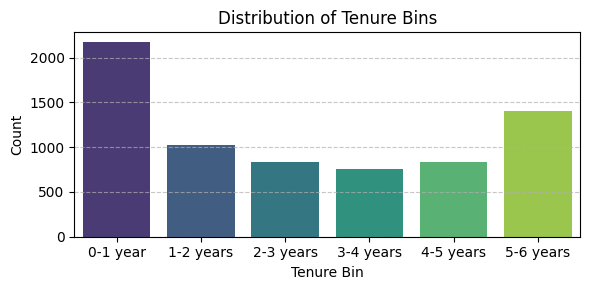

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot size based on the R options (repr.plot.width, repr.plot.height)
plt.figure(figsize=(6, 3))

# Create the bar plot using seaborn, similar to ggplot's geom_bar
sns.countplot(data=df, x='tenure_bin', palette='viridis')

# Add labels and title, similar to theme1 and ggplot's defaults
plt.title('Distribution of Tenure Bins')
plt.xlabel('Tenure Bin')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [65]:
import pandas as pd

# Exclude customerID, tenure, MonthlyCharges, TotalCharges as these are not categorical or already processed
# In R, c(1,6,19,20) would correspond to these columns based on the original df.info() output.
# We will explicitly list the columns to drop to avoid confusion with index changes.
columns_to_drop = ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_bin'] # Added tenure_bin as it's new

# Select categorical columns to create dummy variables. Ensure 'Churn' is included for the target variable.
# Also ensure 'SeniorCitizen' is handled if it's still an object or needs re-encoding.
# Let's assume 'SeniorCitizen' is already processed or we want dummies for it too if it's categorical.

# Get all object and categorical type columns from df, excluding the ones to drop
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop(columns_to_drop, errors='ignore').tolist()

# Create a temporary DataFrame with only the relevant categorical columns for dummy variable creation
telco_cat = df[categorical_cols].copy()

# Creating Dummy Variables and converting them to integers (0/1)
dummy = pd.get_dummies(telco_cat, drop_first=True).astype(int) # Added .astype(int) here

# Clean up column names for statsmodels formula API compatibility
dummy.columns = dummy.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Head of Dummy Variables:")
print(dummy.head())
print("Cleaned Dummy Variable Columns:")
print(dummy.columns.tolist())

Head of Dummy Variables:
   gender_Male  SeniorCitizen_YES  Partner_Yes  Dependents_Yes  \
0        False              False         True           False   
1         True              False        False           False   
2         True              False        False           False   
3         True              False        False           False   
4        False              False        False           False   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber_optic  \
0             False              False                        False   
1              True              False                        False   
2              True              False                        False   
3             False              False                        False   
4              True              False                         True   

   InternetService_No  OnlineSecurity_Yes  OnlineBackup_Yes  ...  \
0               False               False              True  ...   
1              

In [50]:
import pandas as pd

# Combining the dataframes telco_int and dummy by columns
telco_final = pd.concat([telco_int, dummy], axis=1)

# Display the first few rows of the combined dataframe
print("Head of the combined DataFrame (telco_final):")
print(telco_final.head())

Head of the combined DataFrame (telco_final):
     tenure  MonthlyCharges  TotalCharges  gender_Male  SeniorCitizen_YES  \
0 -1.280248       -1.161694     -0.994194        False              False   
1  0.064303       -0.260878     -0.173740         True              False   
2 -1.239504       -0.363923     -0.959649         True              False   
3  0.512486       -0.747850     -0.195248         True              False   
4 -1.239504        0.196178     -0.940457        False              False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0         True           False             False              False   
1        False           False              True              False   
2        False           False              True              False   
3        False           False             False              False   
4        False           False              True              False   

   InternetService_Fiber optic  ...  TechSupport_Yes  StreamingT

In [ ]:
import re

# Clean column names in telco_final for statsmodels
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]+', '_', col) # Replace non-alphanumeric with underscore
        new_col = new_col.strip('_') # Remove leading/trailing underscores
        # Ensure it doesn't start with a number (statsmodels requires this for formula API if used, good practice generally)
        if new_col and new_col[0].isdigit():
            new_col = '_' + new_col
        new_cols.append(new_col)
    df.columns = new_cols
    return df

telco_final = clean_col_names(telco_final)

# Verify cleaned columns
print("Cleaned telco_final columns:")
print(telco_final.columns.tolist())


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# Separate features and target for training
X_train = train.drop('Churn_Yes', axis=1)
y_train = train['Churn_Yes']

# Separate features and target for validation
X_validation = validation.drop('Churn_Yes', axis=1)
y_validation = validation['Churn_Yes']

# Add constant to features for statsmodels (for intercept)
X_train_sm = sm.add_constant(X_train)
X_validation_sm = sm.add_constant(X_validation)

# Train the logistic regression model
# Using sm.GLM with Binomial family for logistic regression
logit_model = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
result = logit_model.fit()

# Print the model summary
print("\nLogistic Regression Model Summary:")
print(result.summary())

# Predict probabilities on the validation set
pred_probabilities = result.predict(X_validation_sm)

# Define the cutoff (from the R code: 0.32)
cutoff = 0.32

# Convert probabilities to binary predictions
predicted_churn = (pred_probabilities >= cutoff).astype(int)

# Get the actual churn values from the validation set
actual_churn = y_validation.astype(int) # Ensure actual_churn is integer type

# Calculate the confusion matrix
conf_final = confusion_matrix(actual_churn, predicted_churn)

# Extract metrics
accuracy = accuracy_score(actual_churn, predicted_churn)
sensitivity = recall_score(actual_churn, predicted_churn, pos_label=1) # Recall for 'Yes' (Churn=1)
specificity = recall_score(actual_churn, predicted_churn, pos_label=0) # Recall for 'No' (Churn=0)

print(f"\nConfusion Matrix:\n{conf_final}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall for Churn=Yes): {sensitivity:.4f}")
print(f"Specificity (Recall for Churn=No): {specificity:.4f}")


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Splitting the data
# Separate features (X) and target (y)
X = telco_final.drop('Churn_Yes', axis=1) # Assuming 'Churn_Yes' is the target variable
y = telco_final['Churn_Yes']

# Split the data into training and validation sets (70% train, 30% validation)
# random_state is used for reproducibility, similar to set.seed()
train, validation = train_test_split(telco_final, test_size=0.3, random_state=123, stratify=telco_final['Churn_Yes'])

print(f"Training set shape: {train.shape}")
print(f"Validation set shape: {validation.shape}")

Training set shape: (4922, 24)
Validation set shape: (2110, 24)


In [86]:
from sklearn.tree import DecisionTreeClassifier

# Separate features and target for training for Decision Tree
X_train_dt = train.drop('Churn_Yes', axis=1)
y_train_dt = train['Churn_Yes']

# Separate features and target for validation for Decision Tree
X_validation_dt = validation.drop('Churn_Yes', axis=1)
y_validation_dt = validation['Churn_Yes']

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=123)

# Train the model using the training data
dt_model.fit(X_train_dt, y_train_dt)

# Predict on the validation set
dt_predictions = dt_model.predict(X_validation_dt)

print("Decision Tree Model trained and predictions made on validation data.")

Decision Tree Model trained and predictions made on validation data.


In [89]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# Calculate the confusion matrix
dt_conf_matrix = confusion_matrix(y_validation_dt, dt_predictions)

# Calculate metrics for the Decision Tree model
dt_accuracy = accuracy_score(y_validation_dt, dt_predictions)
dt_sensitivity = recall_score(y_validation_dt, dt_predictions, pos_label=True) # Recall for 'Yes' (Churn=True)
dt_specificity = recall_score(y_validation_dt, dt_predictions, pos_label=False) # Recall for 'No' (Churn=False)
dt_precision = precision_score(y_validation_dt, dt_predictions, pos_label=True)
dt_f1_score = f1_score(y_validation_dt, dt_predictions, pos_label=True)

print("Decision Tree Model Evaluation:")
print(f"Confusion Matrix:\n{dt_conf_matrix}")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Sensitivity (Recall for Churn=Yes): {dt_sensitivity:.4f}")
print(f"Specificity (Recall for Churn=No): {dt_specificity:.4f}")
print(f"Precision (for Churn=Yes): {dt_precision:.4f}")
print(f"F1-Score (for Churn=Yes): {dt_f1_score:.4f}")

Decision Tree Model Evaluation:
Confusion Matrix:
[[1241  308]
 [ 286  275]]
Accuracy: 0.7185
Sensitivity (Recall for Churn=Yes): 0.4902
Specificity (Recall for Churn=No): 0.8012
Precision (for Churn=Yes): 0.4717
F1-Score (for Churn=Yes): 0.4808


In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split

# The 'Churn_Yes' column is already boolean (0/1), which is suitable as a target for most models.
# No direct equivalent of R's as.factor is strictly necessary for binary classification models
# when the target is represented as 0/1 or True/False.

# Split the data into training and validation sets (70% train, 30% validation)
# random_state is used for reproducibility, similar to set.seed() in R.
# The 'stratify' parameter ensures that the proportion of target variable values is the same in both splits.
train, validation = train_test_split(telco_final, test_size=0.3, random_state=123, stratify=telco_final['Churn_Yes'])

print(f"Training set shape: {train.shape}")
print(f"Validation set shape: {validation.shape}")

Training set shape: (4922, 24)
Validation set shape: (2110, 24)


In [93]:
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target (y) for the training set
X_train_rf = train.drop('Churn_Yes', axis=1)
y_train_rf = train['Churn_Yes']

# Initialize the Random Forest Classifier
# n_estimators is equivalent to ntree in R's randomForest
# max_features is equivalent to mtry in R's randomForest
# random_state is set for reproducibility, similar to set.seed()
rf_model = RandomForestClassifier(n_estimators=500, max_features=4, random_state=123,
                                  oob_score=False, # equivalent to proximity=FALSE/importance=FALSE effect on model fitting
                                  verbose=0) # equivalent to do.trace=FALSE

# Train the model
rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


In [95]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# Separate features and target for validation (these were already defined for DT as X_validation_dt and y_validation_dt)
X_validation_rf = validation.drop('Churn_Yes', axis=1)
y_validation_rf = validation['Churn_Yes']

# Predict on the validation set using the trained Random Forest model
rf_predictions = rf_model.predict(X_validation_rf)

# Calculate the confusion matrix
rf_conf_matrix = confusion_matrix(y_validation_rf, rf_predictions)

# Calculate metrics for the Random Forest model
rf_accuracy = accuracy_score(y_validation_rf, rf_predictions)
rf_sensitivity = recall_score(y_validation_rf, rf_predictions, pos_label=True) # Recall for 'Yes' (Churn=True)
rf_specificity = recall_score(y_validation_rf, rf_predictions, pos_label=False) # Recall for 'No' (Churn=False)
rf_precision = precision_score(y_validation_rf, rf_predictions, pos_label=True)
rf_f1_score = f1_score(y_validation_rf, rf_predictions, pos_label=True)

print("Random Forest Model Evaluation:")
print(f"Confusion Matrix:\n{rf_conf_matrix}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Sensitivity (Recall for Churn=Yes): {rf_sensitivity:.4f}")
print(f"Specificity (Recall for Churn=No): {rf_specificity:.4f}")
print(f"Precision (for Churn=Yes): {rf_precision:.4f}")
print(f"F1-Score (for Churn=Yes): {rf_f1_score:.4f}")

Random Forest Model Evaluation:
Confusion Matrix:
[[1398  151]
 [ 281  280]]
Accuracy: 0.7953
Sensitivity (Recall for Churn=Yes): 0.4991
Specificity (Recall for Churn=No): 0.9025
Precision (for Churn=Yes): 0.6497
F1-Score (for Churn=Yes): 0.5645


In [103]:
from sklearn.linear_model import LogisticRegression

# Separate features and target for training for scikit-learn Logistic Regression
X_train_lr_sk = train.drop('Churn_Yes', axis=1)
y_train_lr_sk = train['Churn_Yes']

# Separate features and target for validation for scikit-learn Logistic Regression
X_validation_lr_sk = validation.drop('Churn_Yes', axis=1)
y_validation_lr_sk = validation['Churn_Yes']

# Initialize the Logistic Regression model
lr_model_sk = LogisticRegression(random_state=123, solver='liblinear') # 'liblinear' is a good choice for small datasets and binary classification

# Train the model
lr_model_sk.fit(X_train_lr_sk, y_train_lr_sk)

# Predict probabilities on the validation set
lr_probabilities_sk = lr_model_sk.predict_proba(X_validation_lr_sk)[:, 1]

# Make binary predictions using a default cutoff (e.g., 0.5)
lr_predictions_sk = (lr_probabilities_sk >= 0.5).astype(int)

print("Scikit-learn Logistic Regression Model trained and predictions made.")

Scikit-learn Logistic Regression Model trained and predictions made.


/tmp/ipykernel_14135/1613179162.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


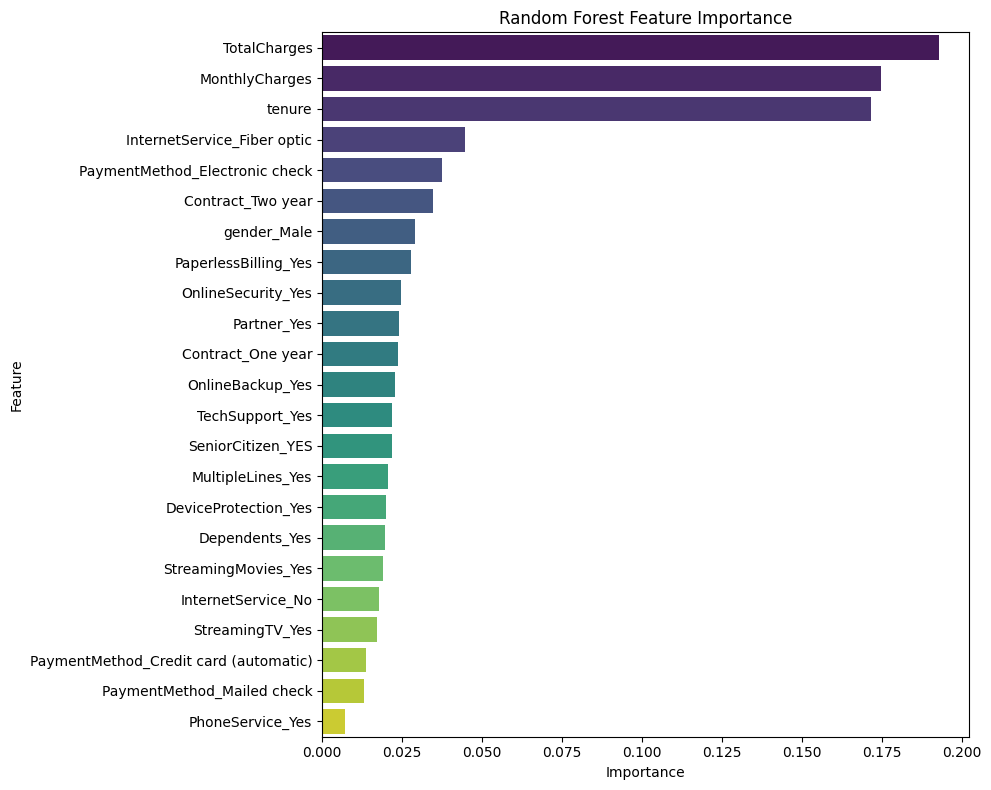

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Get feature names from the training data
feature_names = X_train_rf.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plotting the variable importance
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

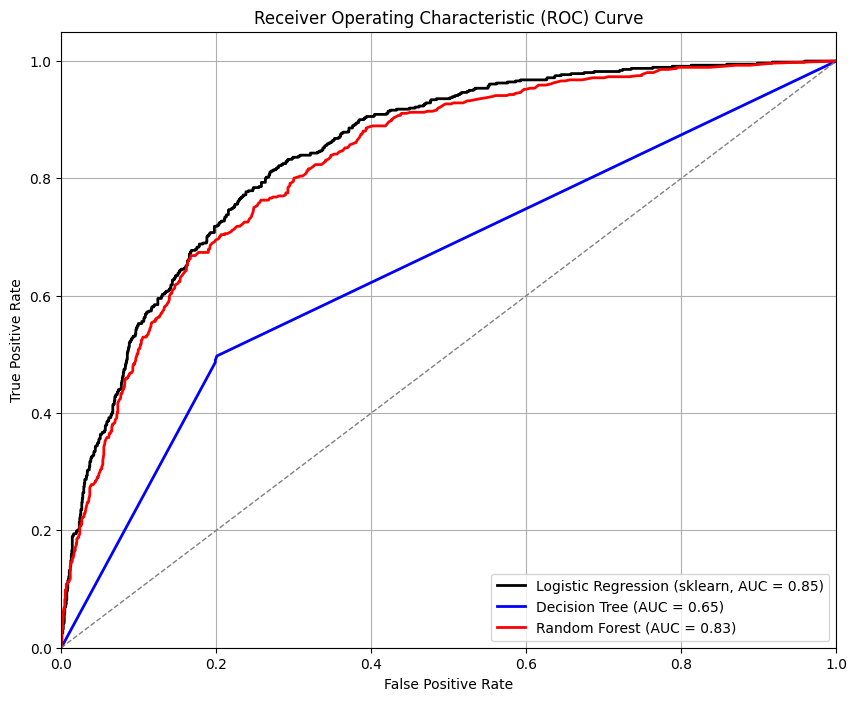

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Set plot size
plt.figure(figsize=(10, 8))

# Get true labels for validation set
y_true = validation['Churn_Yes']

# --- Logistic Regression ROC (using scikit-learn model) ---
# 'lr_probabilities_sk' already exists from cell 7158de28
fpr_lr_sk, tpr_lr_sk, _ = roc_curve(y_true, lr_probabilities_sk)
roc_auc_lr_sk = auc(fpr_lr_sk, tpr_lr_sk)
plt.plot(fpr_lr_sk, tpr_lr_sk, color='black', lw=2, label=f'Logistic Regression (sklearn, AUC = {roc_auc_lr_sk:.2f})')

# --- Decision Tree ROC ---
# Get probabilities for Decision Tree
dt_probabilities = dt_model.predict_proba(X_validation_dt)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_true, dt_probabilities)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# --- Random Forest ROC ---
# Get probabilities for Random Forest
rf_probabilities = rf_model.predict_proba(X_validation_rf)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_true, rf_probabilities)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot configuration
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()